# Open a real sample: <DATASET NAME>
**Goal:** show that one real image and its label/metadata open from a clean kernel with no manual edits.
Do not mark the dataset `verified_open` unless every cell below runs.

Fill in the config cell, then run top to bottom (Kernel > Restart & Run All).

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---- EDIT THESE ----
DATASET_NAME = "STARCOP"
DATA_ROOT = Path("../data/raw/STARCOP/STARCOP_mini")  # raw data stays outside Git
# --------------------

print("Root exists:", DATA_ROOT.exists())

if DATA_ROOT.exists():
    # Find all data files in the extracted directory
    files = sorted([p for p in DATA_ROOT.rglob("*") if p.is_file()])
    print(f"Found {len(files)} total files.")
    
    # Print the first 10 files so you can see their relative paths
    for p in files[:10]:
        print(" -", p.relative_to(DATA_ROOT))
        
    # Auto-pick the first file for testing
    if files:
        SAMPLE_IMAGE = files[0]
        SAMPLE_LABEL = files[1] if len(files) > 1 else None
        
        print("\nAuto-selected files to inspect:")
        print("SAMPLE_IMAGE:", SAMPLE_IMAGE.name)
        if SAMPLE_LABEL:
            print("SAMPLE_LABEL:", SAMPLE_LABEL.name)
    else:
        print("\nNo files found inside DATA_ROOT! Check if unzipping completed successfully.")
else:
    print("DATA_ROOT path does not exist! Make sure your folder structure matches.")

Root exists: True
Found 362 total files.
 - ang20190923t174142_r5826_c168_w151_h151\label_rgba.tif
 - ang20190923t174142_r5826_c168_w151_h151\labelbinary.tif
 - ang20190923t174142_r5826_c168_w151_h151\mag1c.tif
 - ang20190923t174142_r5826_c168_w151_h151\TOA_AVIRIS_2004nm.tif
 - ang20190923t174142_r5826_c168_w151_h151\TOA_AVIRIS_2109nm.tif
 - ang20190923t174142_r5826_c168_w151_h151\TOA_AVIRIS_2310nm.tif
 - ang20190923t174142_r5826_c168_w151_h151\TOA_AVIRIS_2350nm.tif
 - ang20190923t174142_r5826_c168_w151_h151\TOA_AVIRIS_2360nm.tif
 - ang20190923t174142_r5826_c168_w151_h151\TOA_AVIRIS_460nm.tif
 - ang20190923t174142_r5826_c168_w151_h151\TOA_AVIRIS_550nm.tif

Auto-selected files to inspect:
SAMPLE_IMAGE: label_rgba.tif
SAMPLE_LABEL: labelbinary.tif


## 1. Open the image
Use the reader that matches the file format. Uncomment ONE option.

In [6]:
# Option A: GeoTIFF using rasterio
import rasterio

with rasterio.open(SAMPLE_IMAGE) as src:
    image = src.read()  # Reads array into shape [bands, H, W]
    print("CRS:", src.crs)
    print("Transform:", src.transform)
    print("Number of bands:", src.count)

print("shape:", image.shape, "| dtype:", image.dtype)
print("min/max/mean:", np.nanmin(image), np.nanmax(image), np.nanmean(image))
print("NaN count:", int(np.isnan(image).sum()))

CRS: EPSG:32613
Transform: | 5.16, 3.61, 613820.29|
| 3.61,-5.16, 3553557.50|
| 0.00, 0.00, 1.00|
Number of bands: 4
shape: (4, 512, 512) | dtype: uint8
min/max/mean: 0 255 4.01889705657959
NaN count: 0


## 2. Open the label / metadata
Same idea. Record what the label values mean ONLY if the dataset documentation says so.

In [7]:
with rasterio.open(SAMPLE_LABEL) as src:
    mask = src.read(1)  # Read band 1 as the 2D mask array

print("mask shape:", mask.shape, "| dtype:", mask.dtype)
print("unique values:", np.unique(mask))
print("plume pixel fraction:", float((mask > 0).mean()))

mask shape: (512, 512) | dtype: uint8
unique values: [0 1]
plume pixel fraction: 0.00670623779296875


## 3. Visual check
Plot the image (or one band / the enhancement map) with the mask overlaid.

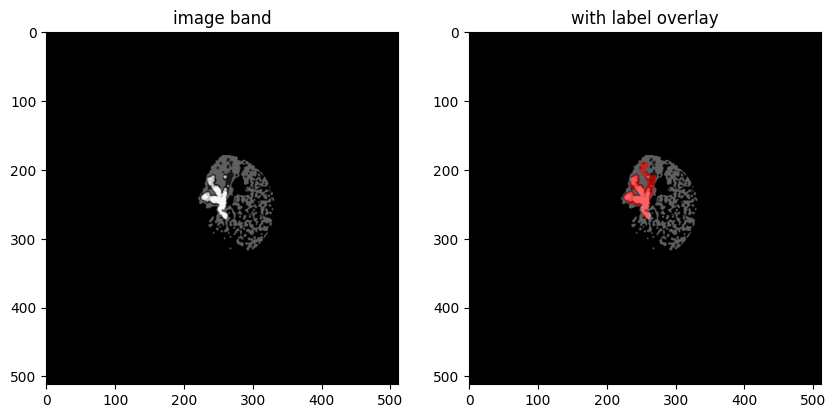

In [8]:
band = image[0] if image.ndim == 3 else image  # Handle multi-channel vs single-channel

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(band, cmap="gray")
ax[0].set_title("image band")

ax[1].imshow(band, cmap="gray")
ax[1].imshow(np.ma.masked_where(mask == 0, mask), alpha=0.6, cmap="autumn")
ax[1].set_title("with label overlay")

plt.show()

## 4. Findings
| Item | Observed |
|---|---|
| File format | GeoTIFF (.tif) |
| Image shape / dtype | (4, 512, 512) / uint8 |
| Number of bands and what they are | 4 bands (RGBA visualization map); individual TOA spectral bands (2004nm, 2109nm, 2310nm, etc.) and mag1c map exist as separate .tif files |
| Label type and values | Binary mask (512, 512) uint8 | Unique values: [0, 1] | Plume fraction: ~0.67% |
| Wind or other metadata present | Flight ID and timestamp in scene directory name; ERA5 wind vectors not directly included in scene folder |
| CRS / geolocation present | Yes (EPSG:32613 - UTM Zone 13N) |
| Anything that failed or needed a workaround | Required `rasterio` reader instead of `np.load`; default auto-picker selected `label_rgba.tif` which was a 4-channel image rather than single TOA band |
| Verdict | `verified_open` |